<a href="https://colab.research.google.com/github/clara-eng/My-AI-Journey/blob/main/Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_wine
import pandas as pd

In [ ]:

#load wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data,columns=wine.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
X, y = wine.data, wine.target


# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

# Create a Decision Tree model without Bagging for comparison
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
base_accuracy = accuracy_score(y_test, y_pred_base)



In [ ]:
# Create a Bagging model using Decision Tree
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # Base model (Decision Tree)
    n_estimators=10,  # Number of estimators (trees)
    max_samples=0.8,  # Percentage of data used per model
    bootstrap=True,  # Enable bootstrapping (sampling with replacement)
    random_state=42
)


In [ ]:

# Train the Bagging model on the training data
bagging_model.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.8,
                  random_state=42)

In [ ]:

# Make predictions on the test set
y_pred_bagging = bagging_model.predict(X_test)

# Compute Accuracy
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)

# Print results
print(f"📌 Accuracy of Decision Tree without Bagging: {base_accuracy:.4f}")
print(f"✅ Accuracy of Bagging with 10 Trees: {bagging_accuracy:.4f}")



📌 Accuracy of Decision Tree without Bagging: 0.9444
✅ Accuracy of Bagging with 10 Trees: 0.9722


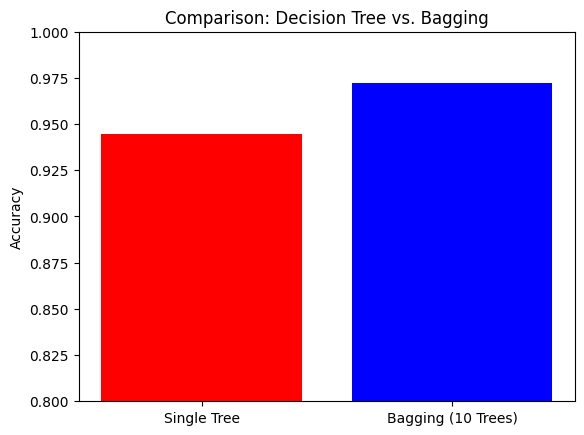

In [ ]:
# Performance comparison
labels = ['Single Tree', 'Bagging (10 Trees)']
accuracies = [base_accuracy, bagging_accuracy]

plt.bar(labels, accuracies, color=['red', 'blue'])
plt.ylabel('Accuracy')
plt.title('Comparison: Decision Tree vs. Bagging')
plt.ylim(0.8, 1)  # Adjust scale
plt.show()
